In [86]:
import yfinance as yf
import pandas as pd

stocks = ["AAPL", "AMZN", "GOOG", "META", "NVDA"]

data = {}

for stock in stocks:
    df = yf.download(stock, start="2023-01-01", end="2025-01-01")
    df["Stock"] = stock
    data[stock] = df

# check one stock
data["NVDA"].head()


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Stock
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,
Date,,,,,,
2023-01-03,14.299909,14.980191,14.081140,14.835344,401277000,NVDA
2023-01-04,14.733453,14.837343,14.225989,14.551645,431324000,NVDA
2023-01-05,14.249962,14.548646,14.133085,14.475723,389168000,NVDA
2023-01-06,14.843338,14.994179,14.019208,14.458744,405044000,NVDA
2023-01-09,15.611527,16.039076,15.125040,15.267890,504231000,NVDA


Clean & prepare data

In [87]:
for stock in stocks:
    df = data[stock]

    # keep only columns that actually exist
    cols = ['Open', 'High', 'Low', 'Close', 'Volume']

    available_cols = [col for col in cols if col in df.columns]

    df = df[available_cols]

    df = df.dropna()

    data[stock] = df

In [88]:
for stock in stocks:
    df = data[stock]

    # flatten MultiIndex columns
    df.columns = df.columns.get_level_values(0)

    data[stock] = df

In [89]:
for stock in stocks:
    df = data[stock]
    df.columns.name = None
    data[stock] = df

In [90]:
data["AAPL"].columns

Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='str')

In [91]:
def add_moving_averages(df):
    df["SMA_20"] = df["Close"].rolling(window=20).mean()
    df["SMA_50"] = df["Close"].rolling(window=50).mean()

    df["EMA_20"] = df["Close"].ewm(span=20, adjust=False).mean()
    df["EMA_50"] = df["Close"].ewm(span=50, adjust=False).mean()

    return df

for stock in stocks:
    data[stock] = add_moving_averages(data[stock])

In [92]:
def compute_rsi(df, window=14):
    delta = df["Close"].diff()

    gain = (delta.where(delta > 0, 0)).rolling(window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window).mean()

    rs = gain / loss
    df["RSI"] = 100 - (100 / (1 + rs))

    return df

for stock in stocks:
    data[stock] = compute_rsi(data[stock])

In [93]:
def compute_macd(df):
    df["EMA_12"] = df["Close"].ewm(span=12).mean()
    df["EMA_26"] = df["Close"].ewm(span=26).mean()

    df["MACD"] = df["EMA_12"] - df["EMA_26"]
    df["Signal"] = df["MACD"].ewm(span=9).mean()

    return df

for stock in stocks:
    data[stock] = compute_macd(data[stock])

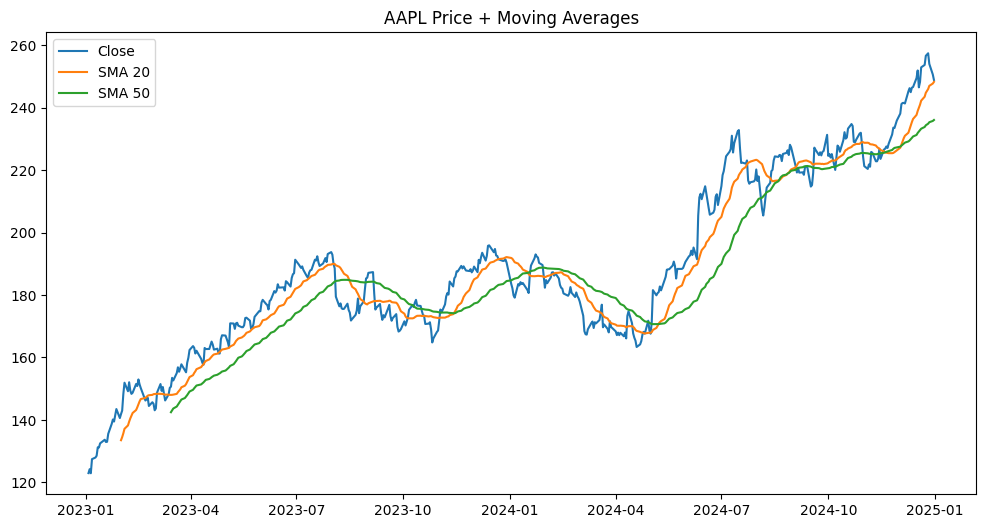

In [94]:
import matplotlib.pyplot as plt

df = data["AAPL"]

plt.figure(figsize=(12,6))
plt.plot(df["Close"], label="Close")
plt.plot(df["SMA_20"], label="SMA 20")
plt.plot(df["SMA_50"], label="SMA 50")
plt.title("AAPL Price + Moving Averages")
plt.legend()
plt.show()

RSI VISUALIZATION (ALL STOCKS)

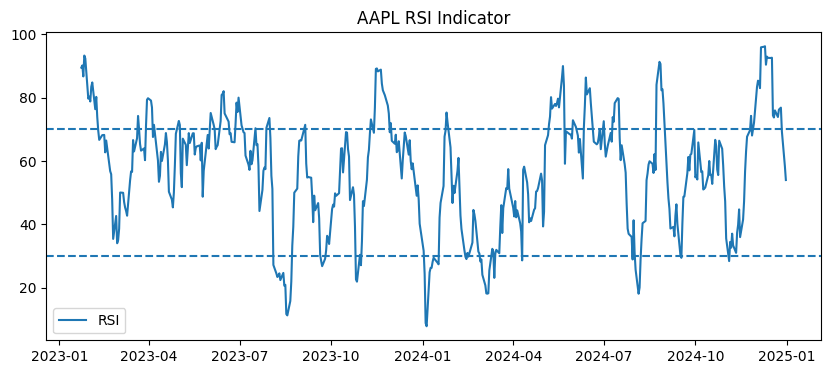

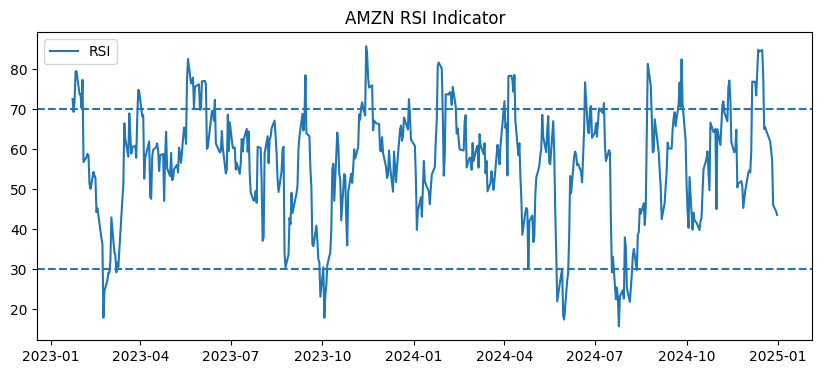

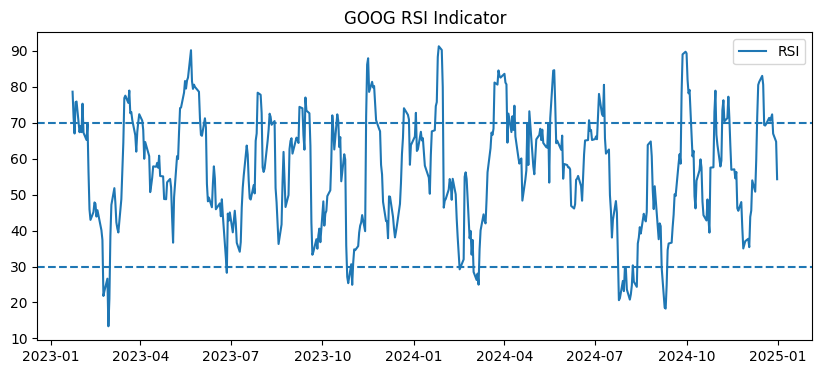

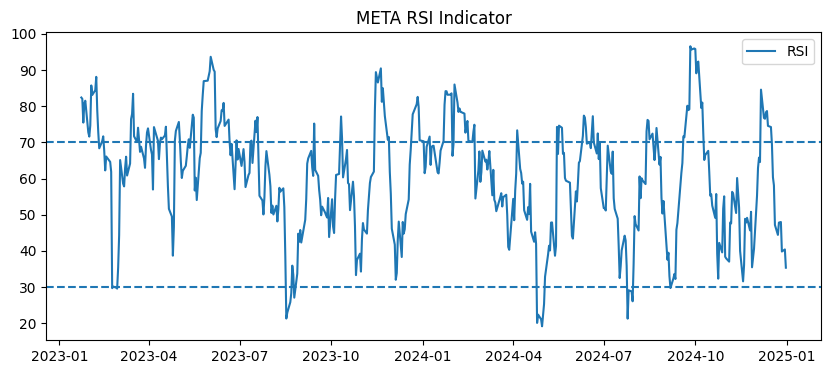

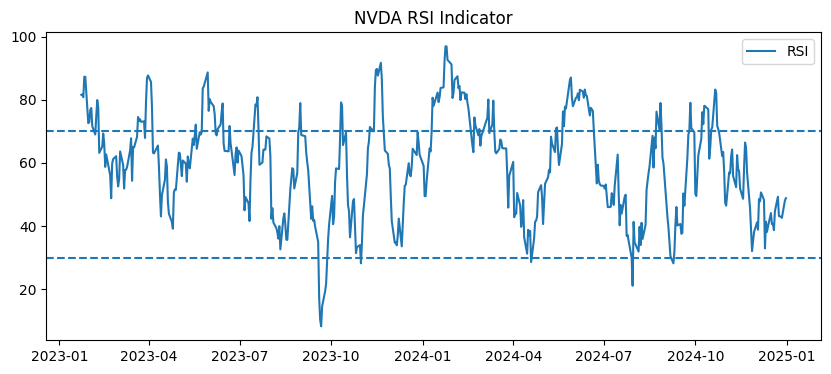

In [95]:
import matplotlib.pyplot as plt

def plot_rsi_all(data, stocks):
    for stock in stocks:
        df = data[stock]

        plt.figure(figsize=(10,4))
        plt.plot(df["RSI"], label="RSI")

        plt.axhline(70, linestyle="--")
        plt.axhline(30, linestyle="--")

        plt.title(f"{stock} RSI Indicator")
        plt.legend()
        plt.show()

plot_rsi_all(data, stocks)

RSI Analysis

RSI was computed using a 14-day rolling window on daily closing prices for each stock (AAPL, AMZN, GOOG, META, NVDA). This indicator was used to measure momentum and identify potential overbought and oversold conditions across different market assets.

In this analysis, RSI values above 70 indicate that a stock may be overbought and potentially due for a price correction, while values below 30 suggest that a stock may be oversold and could experience a rebound.

The indicator was applied individually to each stock to capture differences in volatility and trading behavior across technology companies.
RSI was used as a momentum indicator and later compared with news sentiment in Task 3 to evaluate potential predictive relationships

MACD VISUALIZATION (ALL STOCKS)

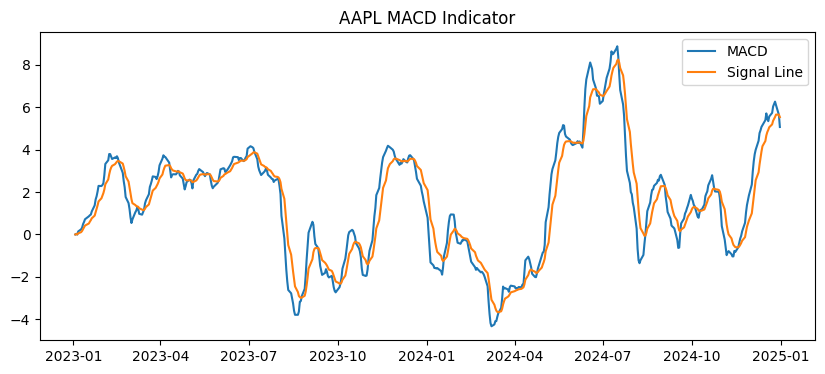

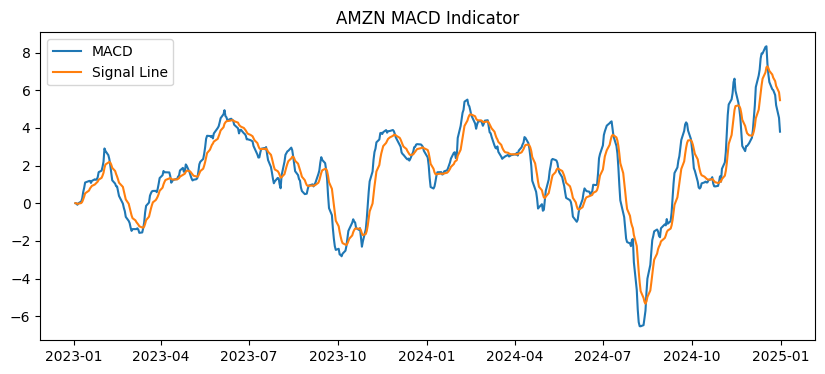

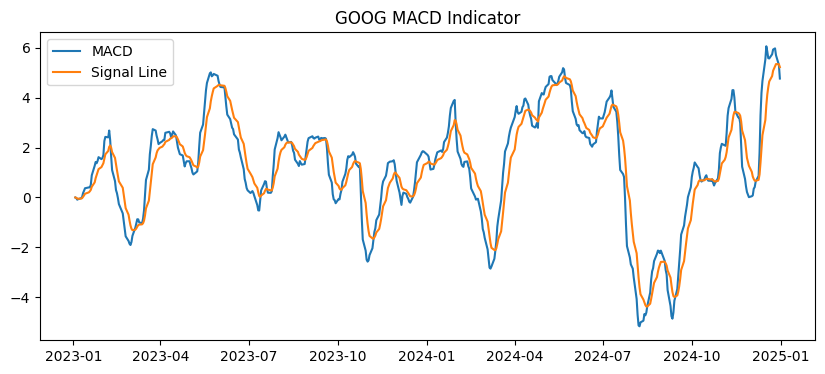

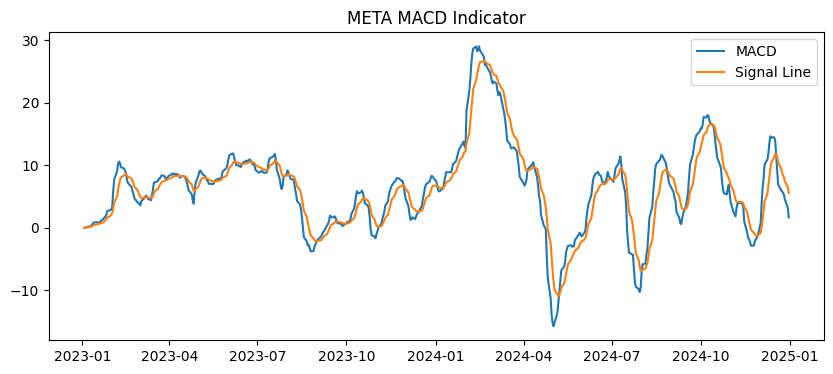

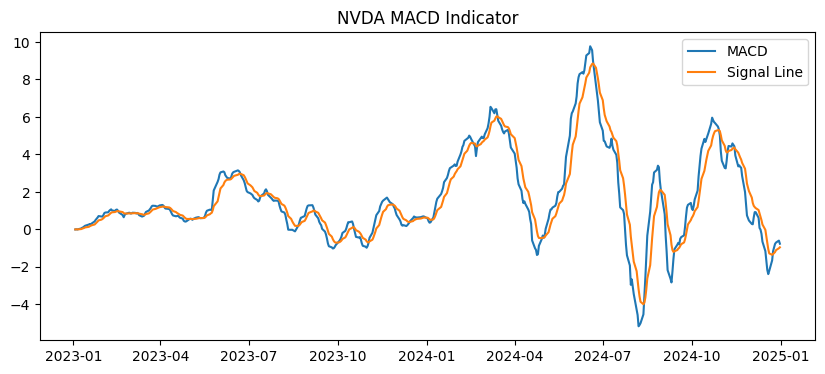

In [96]:
def plot_macd_all(data, stocks):
    for stock in stocks:
        df = data[stock]

        plt.figure(figsize=(10,4))
        plt.plot(df["MACD"], label="MACD")
        plt.plot(df["Signal"], label="Signal Line")

        plt.title(f"{stock} MACD Indicator")
        plt.legend()
        plt.show()

plot_macd_all(data, stocks)

MACD Analysis

MACD was used to identify momentum shifts and trend reversals. Crossovers between MACD and signal line provide potential trading signals.

In [97]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ekram\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [98]:
print(df.columns)

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_20', 'SMA_50', 'EMA_20',
       'EMA_50', 'RSI', 'EMA_12', 'EMA_26', 'MACD', 'Signal'],
      dtype='str')


In [99]:
import os
print(os.getcwd())

c:\Users\ekram\Documents\GitHub\news-sentiment-analysis\notebooks


In [100]:
import os

print(os.listdir("../data/raw"))

['AAPL.csv', 'AMZN.csv', 'GOOG.csv', 'META.csv', 'NVDA.csv', 'raw_analyst_ratings.csv']


In [101]:
import pandas as pd

news_df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

print(news_df.head())
print(news_df.columns)

   Unnamed: 0                                           headline  \
0           0            Stocks That Hit 52-Week Highs On Friday   
1           1         Stocks That Hit 52-Week Highs On Wednesday   
2           2                      71 Biggest Movers From Friday   
3           3       46 Stocks Moving In Friday's Mid-Day Session   
4           4  B of A Securities Maintains Neutral on Agilent...   

                                                 url          publisher  \
0  https://www.benzinga.com/news/20/06/16190091/s...  Benzinga Insights   
1  https://www.benzinga.com/news/20/06/16170189/s...  Benzinga Insights   
2  https://www.benzinga.com/news/20/05/16103463/7...         Lisa Levin   
3  https://www.benzinga.com/news/20/05/16095921/4...         Lisa Levin   
4  https://www.benzinga.com/news/20/05/16095304/b...         Vick Meyer   

                        date stock  
0  2020-06-05 10:30:54-04:00     A  
1  2020-06-03 10:45:20-04:00     A  
2  2020-05-26 04:30:07-04:00 